# Growing stock volume estimation through remote sensing data

This notebook presents the task of growing stock volume (GSV) estimation through remote sensing data. As a study area, we consider forestry in Perm Krai. The dataset was collected in 2020 using ground based measurements.

Each study plot is a circle with a fixed radius of 9m.

We use Sentinel-2 data as resource of remote sensing observations.

In [5]:
%%capture

# install library for spatial data processing
! pip install rasterio geopandas

# install packages for spatial data mapping
! pip install folium matplotlib mapclassify tifffile

In [6]:
import numpy as np
import pandas as pd

import rasterio
import tifffile as tiff
import geopandas as gpd

from shapely.geometry import Point
from shapely.geometry import mapping
from rasterio.mask import mask
from rasterio.windows import from_bounds

import matplotlib.pyplot as plt

Let's download data from https://disk.yandex.ru/d/yqVOed67gKPefg

In [13]:
# Get the data, unpack it, and remove zip file

# if you have mac 
# brew install wget

! wget https://getfile.dokpub.com/yandex/get/https://disk.yandex.ru/d/yqVOed67gKPefg -O ./GSV_dataset.zip
! unzip ./GSV_dataset.zip
! rm -f GSV_dataset.zip

--2026-02-17 16:06:11--  https://getfile.dokpub.com/yandex/get/https://disk.yandex.ru/d/yqVOed67gKPefg
Распознаётся getfile.dokpub.com (getfile.dokpub.com)… 141.11.62.100
Подключение к getfile.dokpub.com (getfile.dokpub.com)|141.11.62.100|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 302 Found
Адрес: https://downloader.disk.yandex.ru/zip/7a1605bceac9953d7d41afd3d34ac94b80e77130741ea9d0e032ee4d9deeae21/6994683e/Y2hqTzhKZzUwb29ndlBvK2xGRnhxejE0QTlxZ05CV0NzY20zamh0MlFJU1dMZW1KRXA3c0lTaDc3V3hDdmMrbnEvSjZicG1SeU9Kb25UM1ZvWG5EYWc9PTo=?uid=0&filename=timberstock.zip&disposition=attachment&hash=chjO8Jg50oogvPo%2BlFFxqz14A9qgNBWCscm3jht2QISWLemJEp7sISh77WxCvc%2Bnq/J6bpmRyOJonT3VoXnDag%3D%3D%3A&limit=0&owner_uid=106881242&tknv=v3 [переход]
--2026-02-17 16:06:14--  https://downloader.disk.yandex.ru/zip/7a1605bceac9953d7d41afd3d34ac94b80e77130741ea9d0e032ee4d9deeae21/6994683e/Y2hqTzhKZzUwb29ndlBvK2xGRnhxejE0QTlxZ05CV0NzY20zamh0MlFJU1dMZW1KRXA3c0lTaDc3V3hDdmMrbnEvSjZicG1Se

The dataset includes the following files:

*   2022.tif --- composite image of Sentinel-2 for 2022
*   2023.tif --- composite image of Sentinel-2 for 2023    
*   age.tif --- additional data with forest age estimated by ML model    
*   chm.tif --- canopy height model (chm)
*   dem.tif --- digital elevation model (dem)      
*   data.csv --- data with inventory plots' coordinates and taxation measurements for height and timber volume   

All data have the spatial resolution of 10m per pixel and the same extention.

Satellite images have 10 spectral bands with original resolution from 10 to 20 m per pixel that were brought to 10 m resolution.

The structure of taxation data is the following: we have a set of plots with coordinates and reference data for these plots. Each plot has a radius of 9m. Therefore, each plot cover a several pixels.

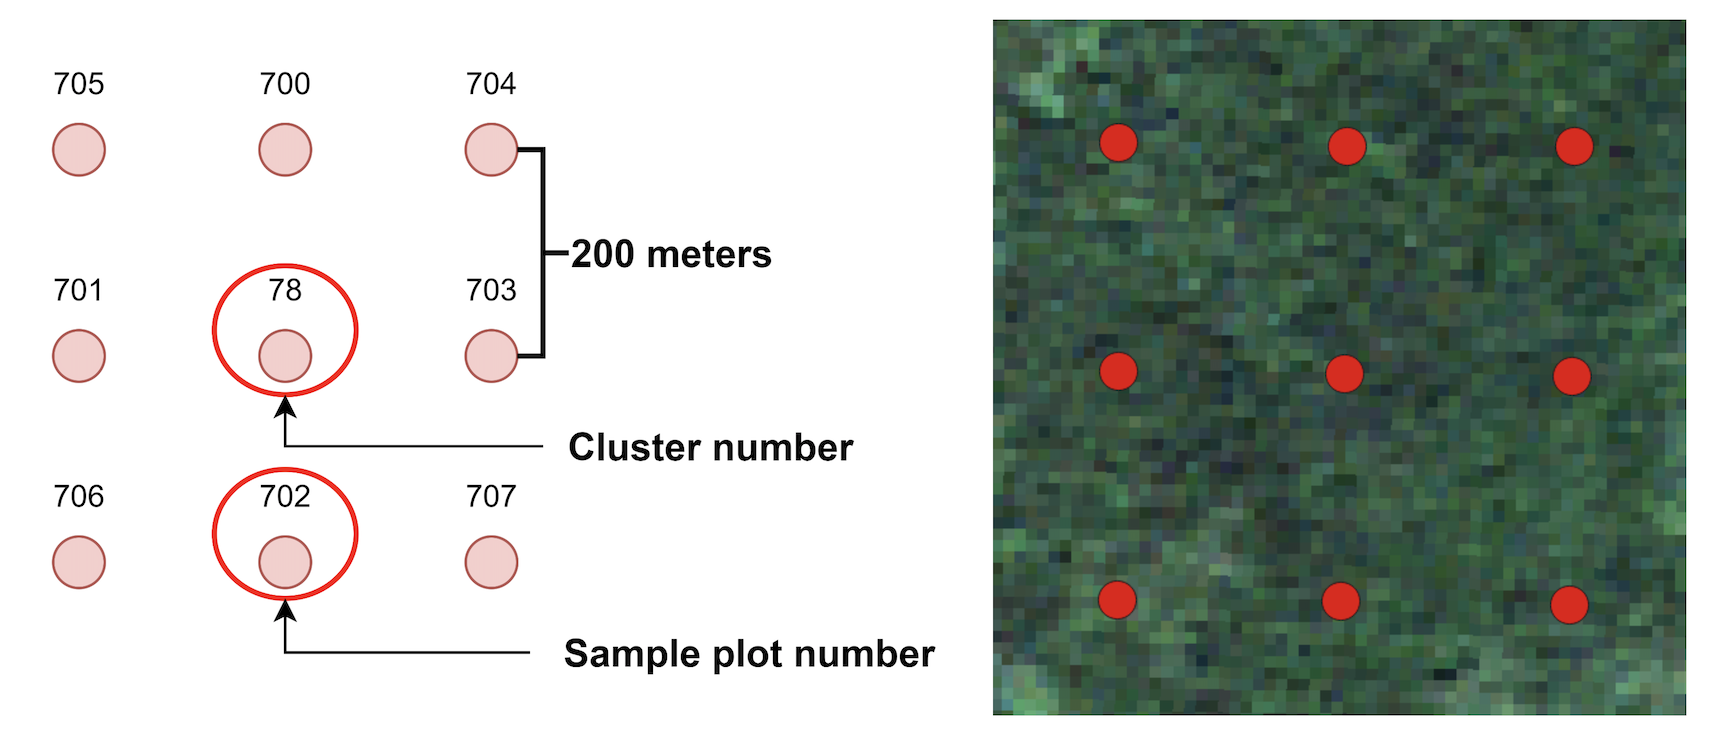

## Brief note about libraries to work with environmental raster data

Here are some TIFF details:

* TIFF stands for Tage Image File Format
* It is often used for environmental and medical imaging
* It contains metadata that can be used both for data processing and visualization in GIS systems

The most popular Python libraries to work with TIFF files are:

* <a href="https://pypi.org/project/rasterio/">rasterio</a> : this is a library that is useful for GIS processing in general
* <a href="https://pypi.org/project/tifffile/">tiffile</a> : more focused on TIFF file processing

# Code to convert data from GEE into format of Sentinel-Hub

When we download imagery from GEE, it returns 23 bands in the raster file. However, for our study, we need only 10 spectral bands with spatial resolution from 10 t0 20 m. These bands are 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12'. The corresponding bands in GEE file have the following indices 1, 2, 3, 4, 5, 6, 7, 8, 10, 11

Let's read, extract channels, and write new file with the same resolution band only 10 spectral bands.

In the shared dataset images are already preprocessed, so you should skip this code.

In [14]:
# set file name
file_path = 'timberstock/2022.tif'

# set path to output file
outputpath = '2022.tif'

# read file and meta data
with rasterio.open(file_path) as src:
    meta = src.meta
    image = src.read()

In [15]:
image.shape

(10, 7200, 10000)

In [16]:
meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 65535.0,
 'width': 10000,
 'height': 7200,
 'count': 10,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 40N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(10.0, 0.0, 485999.0,
        0.0, -10.0, 6804001.0)}

In [17]:
# create new empty image with the same resolution but 10 bands
image_new = np.zeros((10, image.shape[1], image.shape[2]), dtype='uint16')

In [18]:
image_new.shape

(10, 7200, 10000)

In [20]:
# check new and all indices
for ind, band in enumerate([1, 2, 3, 4, 5, 6, 7, 8, 10, 11]):
    print(ind, band)

0 1
1 2
2 3
3 4
4 5
5 6
6 7
7 8
8 10
9 11


In [ ]:
# copy the necessary bands to new file
for ind, band in enumerate([1, 2, 3, 4, 5, 6, 7, 8, 10, 11]):
    image_new[ind] = image[band]

In [ ]:
out_meta = meta.copy()
out_meta['count'] = 10 # change number of bands in the metadata properties
with rasterio.open(fp=outputpath, # outputpath_name
             mode='w',**out_meta) as dst:
             dst.write(image_new) # the numer one is the number of bands

# Visualize raster data

Let's open and visualize raster data with satellite images and environmental features.

In [31]:
# read satellite composite image
with rasterio.open('timberstock/2022.tif') as src:
    meta = src.meta
    image = src.read()

# read canopy height model
with rasterio.open('timberstock/chm.tif') as src:
    chm = src.read()

# read digital elevation model
with rasterio.open('timberstock/dem.tif') as src:
    dem = src.read()

# read forest age
with rasterio.open('timberstock/age.tif') as src:
    age = src.read()

In [32]:
meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 65535.0,
 'width': 10000,
 'height': 7200,
 'count': 10,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 40N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(10.0, 0.0, 485999.0,
        0.0, -10.0, 6804001.0)}

Check the shape of each file

In [23]:
image.shape, chm.shape, dem.shape, age.shape

((10, 7200, 10000), (1, 7200, 10000), (1, 7200, 10000), (1, 7200, 10000))

#### Digital Elevation Models
DEMs provide numerical elevation points representing surface topography. While often used to refer to bare-earth, they can sometimes include surface objects, though technically that is a Digital Surface Model (DSM).

![](https://earthdata.nasa.gov/s3fs-public/styles/hds_generic_card/public/2021-12/Virgin_River_Nevada.jpg?VersionId=srfhZ4kl8_OWLeVSD3_XVYWtctiu0vhV&itok=ZydO-8eP)

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x122159d90>)

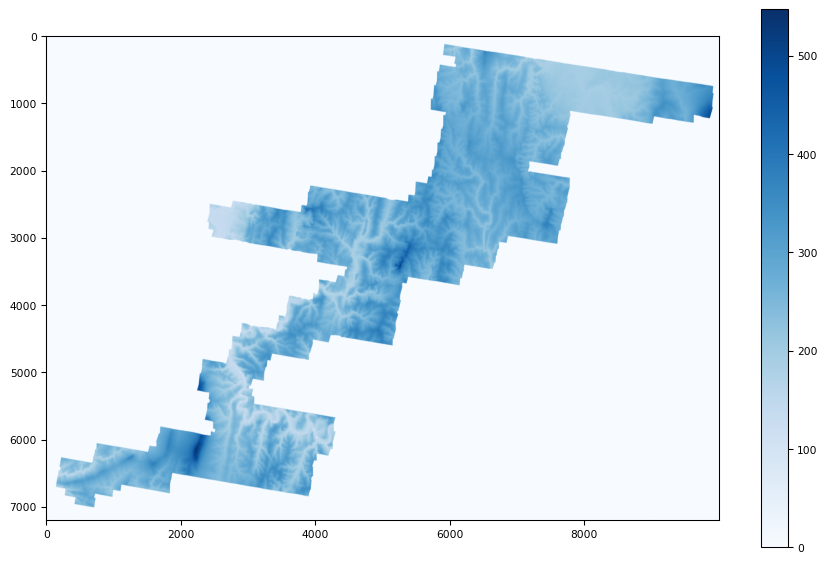

In [24]:
tiff.imshow(dem, cmap='Blues')

#### Canopy Height Model
![](https://i.sstatic.net/1l3EA.png)


(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x1182e7980>)

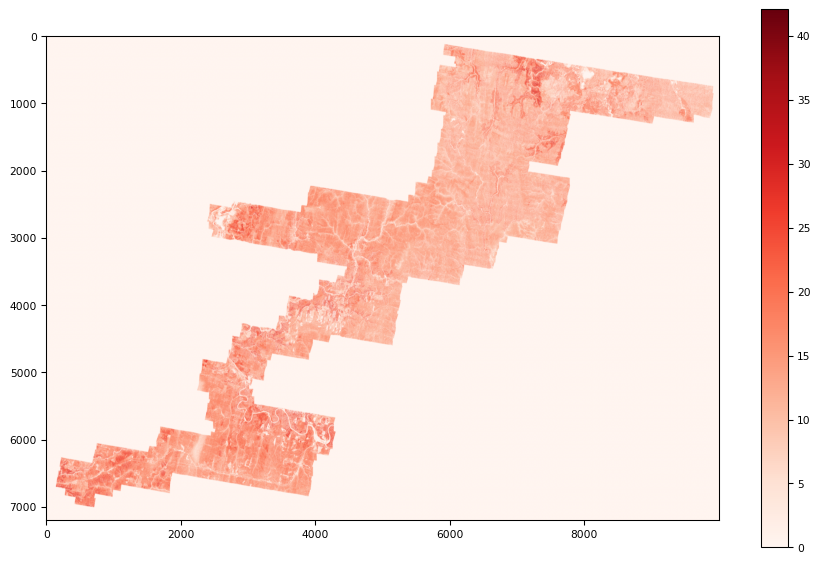

In [25]:
tiff.imshow(chm, cmap='Reds')

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x1185be4b0>)

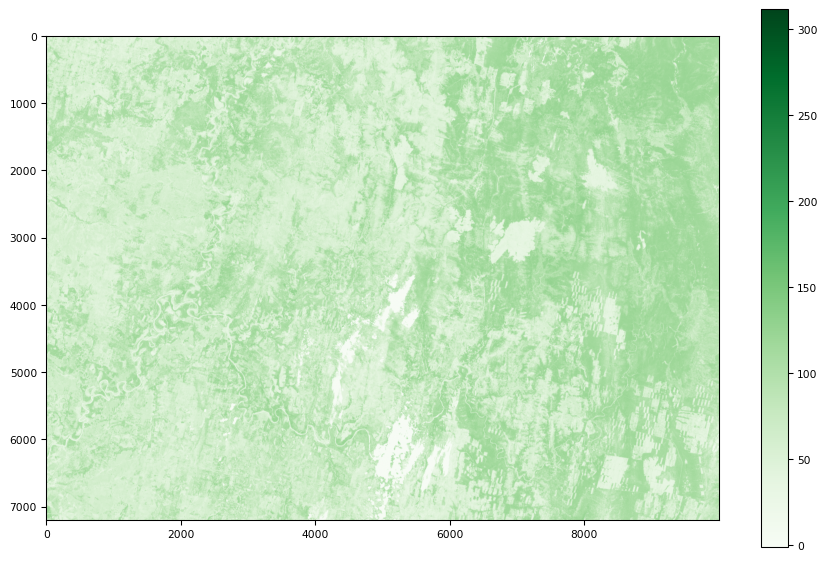

In [26]:
tiff.imshow(age, cmap='Greens')

In [27]:
meta['nodata']

65535.0

In [28]:
image = image.astype(float)
image[image==meta['nodata']] = np.nan

In [33]:
image = np.clip(image, 0, 1000)

(<Figure size 988.8x604.8 with 3 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x11a885eb0>)

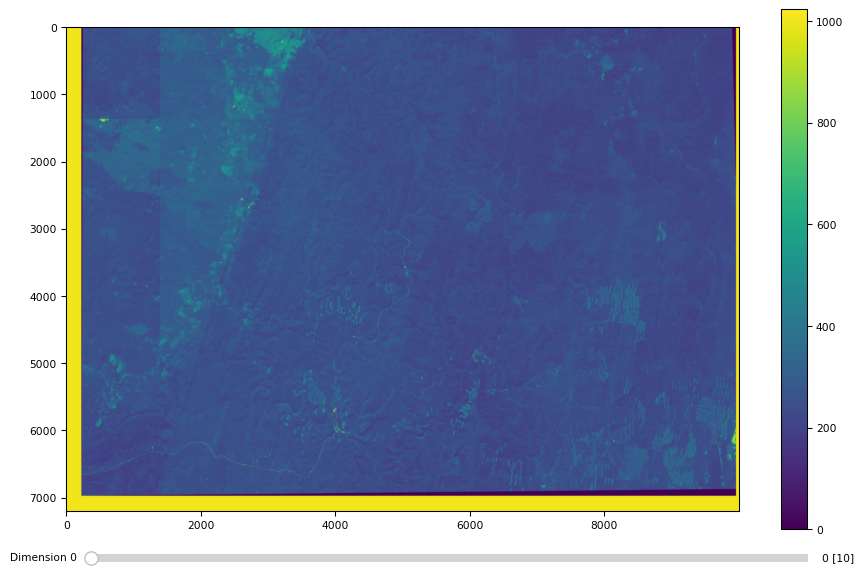

In [34]:
tiff.imshow(image)

(<Figure size 988.8x604.8 with 1 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x118827830>)

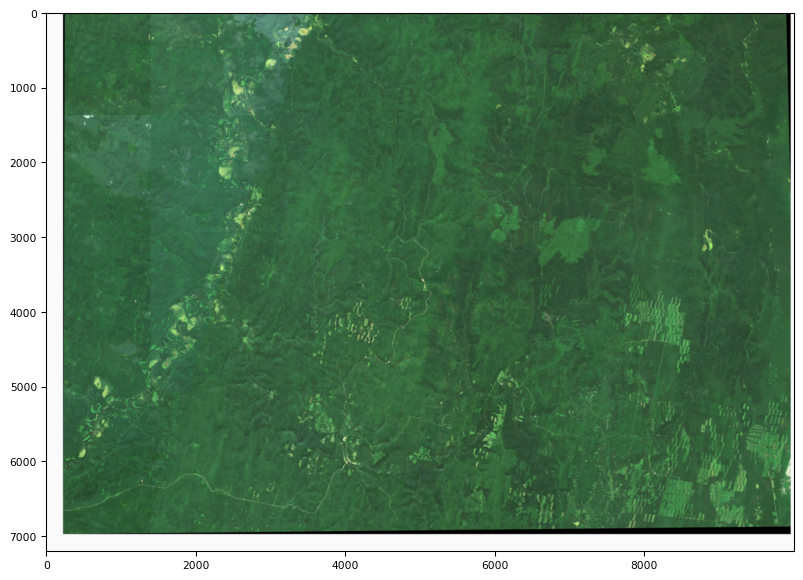

In [35]:
tiff.imshow(np.asarray([image[2,:,:], image[1,:,:], image[0,:,:]]))

We can compute statistics for these bands

In [36]:
stats = []

for band in image:
    stats.append({
    'min': band.min().round(3),
    'mean': band.mean().round(3),
    'median': np.median(band).round(3),
    'max': band.max().round(3)})

In [37]:
stats

[{'min': np.uint16(0),
  'mean': np.float64(295.098),
  'median': np.float64(248.0),
  'max': np.uint16(1000)},
 {'min': np.uint16(0),
  'mean': np.float64(437.58),
  'median': np.float64(403.0),
  'max': np.uint16(1000)},
 {'min': np.uint16(0),
  'mean': np.float64(263.813),
  'median': np.float64(215.0),
  'max': np.uint16(1000)},
 {'min': np.uint16(0),
  'mean': np.float64(651.096),
  'median': np.float64(631.0),
  'max': np.uint16(1000)},
 {'min': np.uint16(0),
  'mean': np.float64(989.413),
  'median': np.float64(1000.0),
  'max': np.uint16(1000)},
 {'min': np.uint16(0),
  'mean': np.float64(989.621),
  'median': np.float64(1000.0),
  'max': np.uint16(1000)},
 {'min': np.uint16(0),
  'mean': np.float64(989.22),
  'median': np.float64(1000.0),
  'max': np.uint16(1000)},
 {'min': np.uint16(0),
  'mean': np.float64(989.596),
  'median': np.float64(1000.0),
  'max': np.uint16(1000)},
 {'min': np.uint16(0),
  'mean': np.float64(955.646),
  'median': np.float64(1000.0),
  'max': np.uint

We then merge all raster bands to create a single feature space. The shape os a new raster will be 10 spactral bands + chm + dem + age. Totally, we will obtain 13 bands:

'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'CHM', 'DEM', 'AGE'

In [38]:
with rasterio.open('timberstock/2022.tif') as src: # composite Sentinel-2 for 2023
    meta = src.meta
    image = src.read() # 10 bands

with rasterio.open('timberstock/chm.tif') as src: # canopy height model - height
    chm = src.read()

with rasterio.open('timberstock/dem.tif') as src:
    dem = src.read()

with rasterio.open('timberstock/age.tif') as src:
    age = src.read()

result_img = np.concatenate((image, chm, dem, age), axis=0)

In [39]:
outputpath = 'merged_data.tif'
out_meta = meta.copy()
out_meta['count'] = 13 # change number of bands in the metadata properties
with rasterio.open(fp=outputpath,
             mode='w',**out_meta) as dst:
             dst.write(result_img)

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x118b02ae0>)

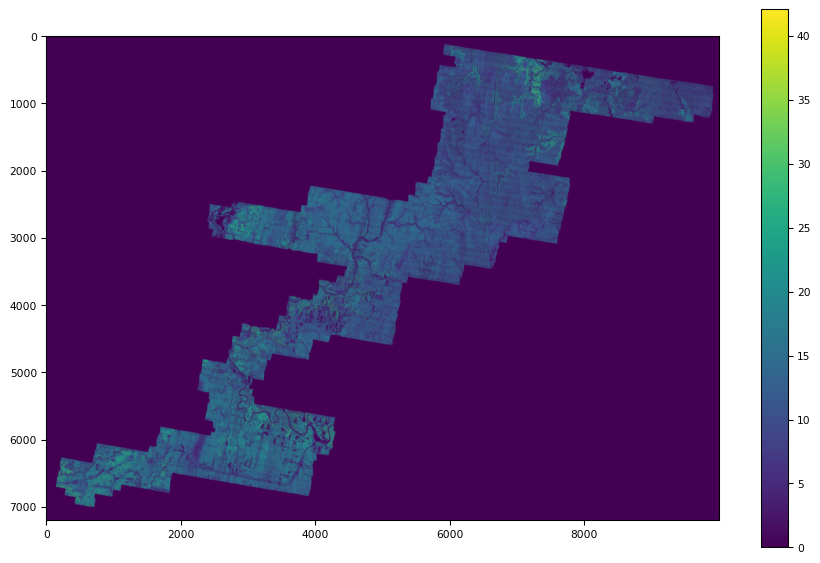

In [42]:
tiff.imshow(result_img[-3, :, :])

In [43]:
merged_img_path = 'merged_data.tif'
with rasterio.open(merged_img_path) as src:
    meta = src.meta
    image = src.read()

In [44]:
meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 65535.0,
 'width': 10000,
 'height': 7200,
 'count': 13,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 40N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(10.0, 0.0, 485999.0,
        0.0, -10.0, 6804001.0)}

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x118b89e20>)

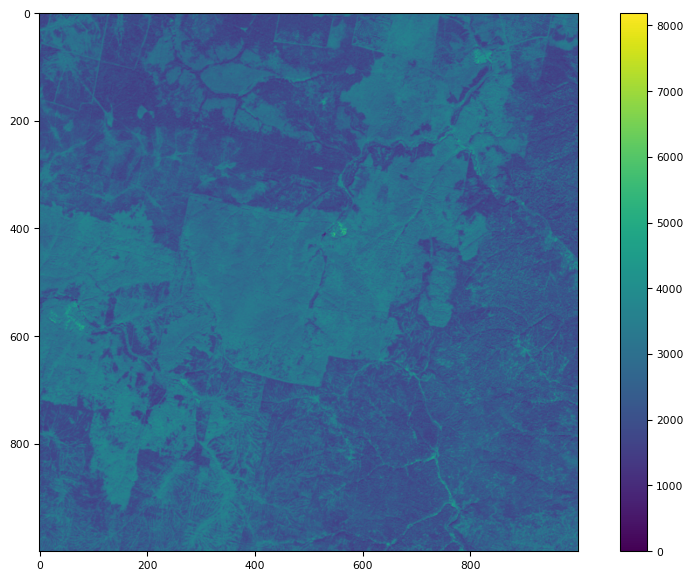

In [45]:
tiff.imshow(image[6, 1000:2000, 1000:2000])

In [46]:
np.max(image)

np.uint16(65535)

In [47]:
meta['crs']

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 40N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

# Create dataset in CSV format

We can read csv file with taxation data. It contains coordinates in format of latitude (y), and longitude (x). The projection of this data is crs='EPSG:32640'. Field based measurements contain timber volume and forest height.

In [48]:
# specify path and read vector polygon shapefile

df_path = 'timberstock/data.csv'
df = pd.read_csv(df_path)
df.head()

,y,x,V,H
0,6745060.540,526642.170,360,22.0
1,6743223.665,526509.015,215,24.3
2,6742455.950,525509.350,514,24.0
3,6740124.512,522847.614,319,19.3
4,6739308.912,524661.734,267,17.8


In [49]:
print(df.size)

3672


In [50]:
print(df.shape)

(918, 4)


Now let's create geo pandas dataframe to process coordinates into georeferenced data, so then we can create polygons.

GeoPandas is based on the pandas. It extends pandas data types to include geometry columns and perform spatial operations.

The main data structure in GeoPandas is the GeoDataFrame that extends the pandas DataFrame. So all the base DataFrame operations can be performed on the GeoDataFrame. The GeoDataFrame contains one or more GeoSeries (that extends pandas Series) each of which contains geometries in a different projection (GeoSeries.crs).

Here is the link for the documentation for [geopandas](https://geopandas.org/en/stable/).

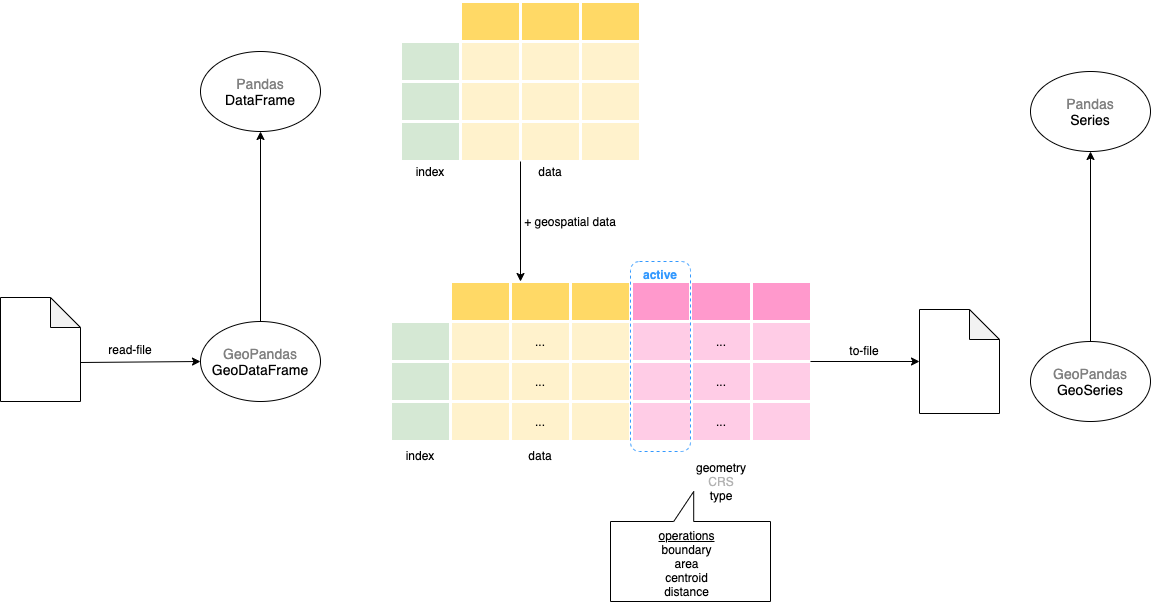

Here we convert points of latitude and longitude into points

In [51]:
geometry = [Point(lon, lat) for lon, lat in zip(df['x'], df['y'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:32640')
gdf.head()

,y,x,V,H,geometry
0,6745060.540,526642.170,360,22.0,POINT (526642.17 6745060.54)
1,6743223.665,526509.015,215,24.3,POINT (526509.015 6743223.665)
2,6742455.950,525509.350,514,24.0,POINT (525509.35 6742455.95)
3,6740124.512,522847.614,319,19.3,POINT (522847.614 6740124.512)
4,6739308.912,524661.734,267,17.8,POINT (524661.734 6739308.912)


In [52]:
print(gdf.dtypes)

y            float64
x            float64
V              int64
H            float64
geometry    geometry
dtype: object


We can now visualize spatial distribution of taxation plots in the georefernces map

In [53]:
gdf.explore()

In [ ]:
# code to save map

# m = gdf.explore()
# outfp = r"<your dir path>\base_map.html"
# m.save(outfp)

We set buffer distance to 9m and update geometry with new shapes, namely the POLYGON format

In [54]:
buffer_distance = 9  # radius in meters
gdf.geometry = gdf.buffer(buffer_distance)

In [55]:
gdf.to_file('dataframe.geojson', driver='GeoJSON')

In [56]:
gdf.head()

,y,x,V,H,geometry
0,6745060.540,526642.170,360,22.0,"POLYGON ((526651.17 6745060.54, 526651.127 674..."
1,6743223.665,526509.015,215,24.3,"POLYGON ((526518.015 6743223.665, 526517.972 6..."
2,6742455.950,525509.350,514,24.0,"POLYGON ((525518.35 6742455.95, 525518.307 674..."
3,6740124.512,522847.614,319,19.3,"POLYGON ((522856.614 6740124.512, 522856.571 6..."
4,6739308.912,524661.734,267,17.8,"POLYGON ((524670.734 6739308.912, 524670.691 6..."


In [57]:
gdf.explore()

<Axes: >

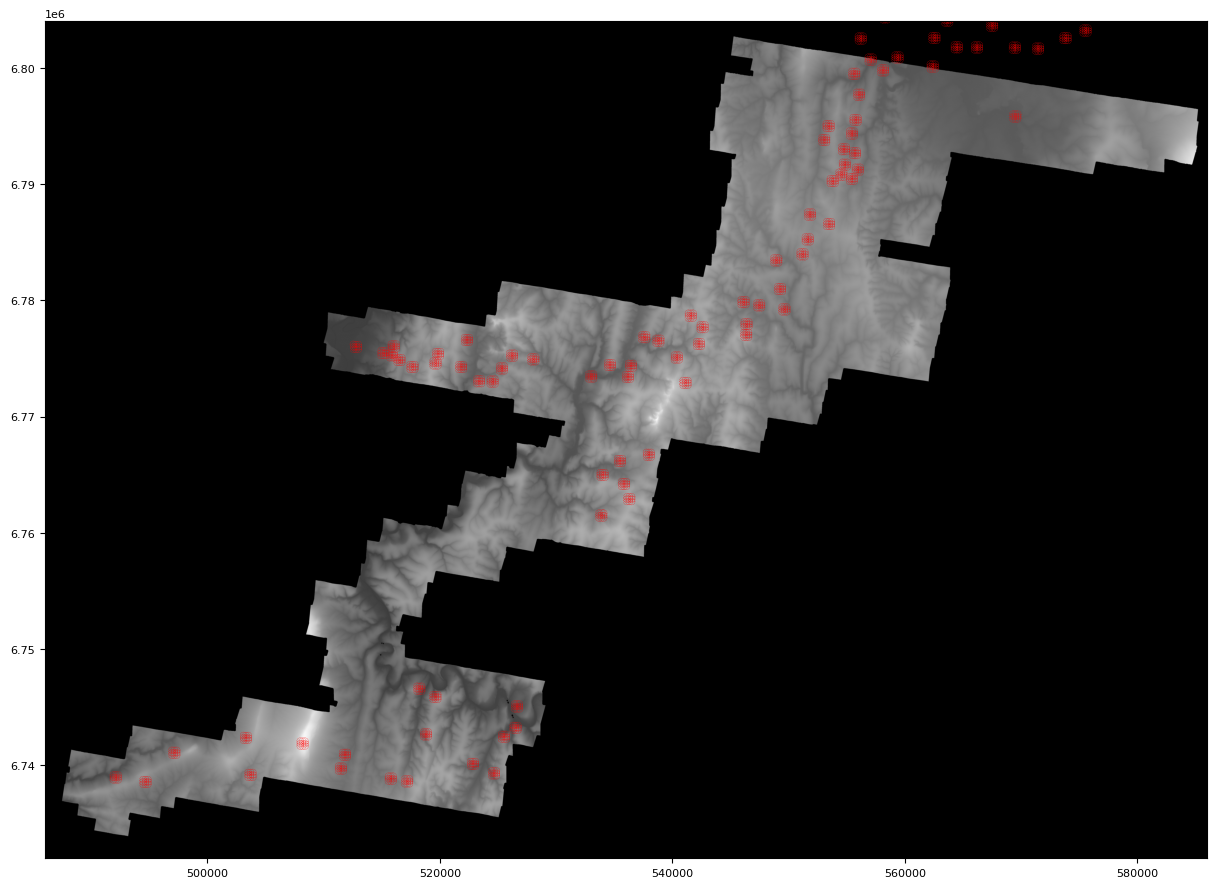

In [58]:
from rasterio.plot import show

ax = gdf.boundary.plot(color="red", figsize=(15,15), linewidth=5)

demfile = "timberstock/dem.tif" #r"merged_data.tif"
src = rasterio.open(demfile)
show(src, cmap="gray", ax=ax)

In [ ]:
# tmp = np.zeros((10, 25, 25), dtype='uint16')
# tmp1 = tmp.reshape(10, -1)
# tmp1.shape

(10, 625)

To create features for our dataset, we will calculate the following statistics for each inventory plot:

* min,
* max,
* mean,
* median,
* std

Let's create the header for dataframe with all combinations of these statistics and bands' values in the merged image  

In [59]:
combinations = []
cols = ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'CHM', 'DEM', 'AGE']
agg_t = ['min', 'max', 'mean', 'median', 'std']
# Generate combinations
for agg in agg_t:
    for col in cols:
        combinations.append(f"{col}_{agg}")

combinations.append(f"lon") # add header for coordinates
combinations.append(f"lat") # add header for coordinates
combinations.append(f"V") # add the target with timber volume
result_df = pd.DataFrame(columns=combinations)

In [60]:
result_df

,B02_min,B03_min,B04_min,B05_min,B06_min,B07_min,B08_min,B8A_min,B11_min,B12_min,...,B08_std,B8A_std,B11_std,B12_std,CHM_std,DEM_std,AGE_std,lon,lat,V


Let's fill the dataframe with computed values for each individual plot.

In [61]:
%%capture
merged_img_path = 'merged_data.tif' # raster with all spatial features

with rasterio.open(merged_img_path) as src:

    for geometry, lon, lat, vol in zip(gdf.geometry, gdf['x'], gdf['y'], gdf['V']):

        x_list, y_list = geometry.exterior.xy # latitude (y), and longitude (x)

        left = np.min(x_list)
        bottom = np.min(y_list)
        right = np.max(x_list)
        top = np.max(y_list)
        cropped_image = src.read(window=from_bounds(left, bottom, right, top, src.transform))

        row, col = src.index(lon, lat)
        feature_vec = cropped_image.reshape(13, -1)
        feature_vec = feature_vec.astype('float')
        feature_vec[feature_vec == 0] = np.nan

        if feature_vec.size == 0: # is zero-size array
            continue
        nanmin = np.nanmin(feature_vec, axis=1)
        nanmax = np.nanmax(feature_vec, axis=1)
        nanmean = np.nanmean(feature_vec, axis=1)
        nanmedian = np.nanmedian(feature_vec, axis=1)
        nanstd = np.nanstd(feature_vec, axis=1)
        merged_array = np.concatenate((nanmin, nanmax, nanmean,
                                        nanmedian, nanstd,
                                        [lon, lat, vol]))
        tmp = pd.DataFrame([merged_array], columns=combinations)
        result_df = pd.concat([result_df, tmp])

In [62]:
result_df.dropna(inplace=True)

In [63]:
print('Number of plots after drop nan values: ', len(result_df), ', number of all plots: ', len(gdf.geometry))

Number of plots after drop nan values:  686 , number of all plots:  918


In [64]:
result_df

,B02_min,B03_min,B04_min,B05_min,B06_min,B07_min,B08_min,B8A_min,B11_min,B12_min,...,B08_std,B8A_std,B11_std,B12_std,CHM_std,DEM_std,AGE_std,lon,lat,V
0,240.0,385.0,227.0,612.0,1799.0,2185.0,2032.0,2343.0,1077.0,495.0,...,148.71176,47.399895,33.327916,12.031209,2.828427,1.0,4.866981,526642.17,6745060.54,360.0
0,226.0,343.0,199.0,539.0,1635.0,2012.0,1819.0,2091.0,868.0,406.0,...,108.674974,64.0,27.0,2.0,6.128259,1.581139,6.422616,526509.015,6743223.665,215.0
0,235.0,356.0,190.0,536.0,1512.0,1833.0,1839.0,2038.0,915.0,397.0,...,104.0,0.0,0.0,0.0,1.5,0.5,9.0,525509.35,6742455.95,514.0
0,227.0,400.0,205.0,636.0,2231.0,2801.0,2852.0,3015.0,1222.0,529.0,...,196.32037,40.0,24.0,3.0,1.920286,0.433013,3.082207,522847.614,6740124.512,319.0
0,245.0,393.0,204.0,656.0,2109.0,2655.0,2466.0,2824.0,1185.0,522.0,...,355.123218,283.5,71.0,23.0,1.299038,1.118034,16.976086,524661.734,6739308.912,267.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,266.0,452.0,278.0,739.0,1857.0,2140.0,2132.0,2309.0,1232.0,620.0,...,36.113536,22.0,8.5,3.5,1.0,0.0,2.772634,569703.14,6796007.509,114.0
0,273.0,453.0,279.0,734.0,1919.0,2226.0,2118.0,2370.0,1270.0,632.0,...,101.532015,13.5,2.5,12.5,4.242641,0.0,1.47902,569302.622,6795809.739,204.0
0,224.0,366.0,207.0,575.0,1569.0,1879.0,1823.0,2002.0,1024.0,487.0,...,42.792377,34.5,24.0,6.5,4.921608,0.0,6.595453,569303.01,6795609.509,121.0
0,252.0,436.0,272.0,670.0,1741.0,2107.0,2077.0,2288.0,1097.0,548.0,...,46.724592,0.0,0.0,0.0,3.091206,0.0,1.870829,569504.768,6795607.902,156.0


In [65]:
def calculate_ndvi(b08, b04):
    return (b08 - b04) / (b08 + b04)

def calculate_evi(b08, b04, b02):
    return 2.5 * (b08 - b04) / (b08 + 6 * b04 - 7.5 * b02 + 1)

# Calculate NDVI
# for stat in ['min', 'max', 'sum', 'mean', 'median', 'std', 'var']:
#     result_df[f'NDVI_{stat}'] = calculate_ndvi(result_df[f'B08_{stat}'], result_df[f'B04_{stat}'])

# # Calculate EVI
# for stat in ['min', 'max', 'sum', 'mean', 'median', 'std', 'var']:
#     result_df[f'EVI_{stat}'] = calculate_evi(result_df[f'B08_{stat}'], result_df[f'B04_{stat}'], result_df[f'B02_{stat}'])

In [ ]:
out_path = 'train_polygon.csv'
result_df.to_csv(out_path, index=False)

# Data analysis

<Axes: ylabel='Density'>

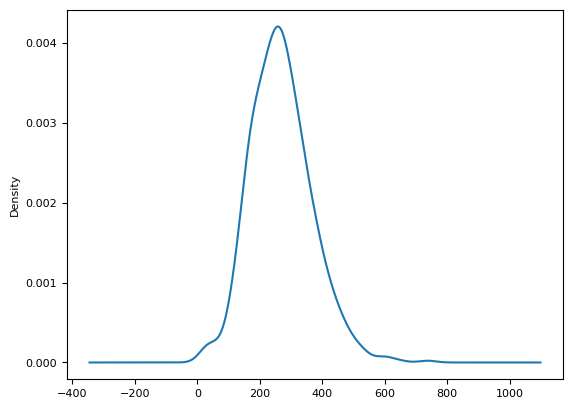

In [66]:
result_df['V'].plot.kde()

<Axes: ylabel='Frequency'>

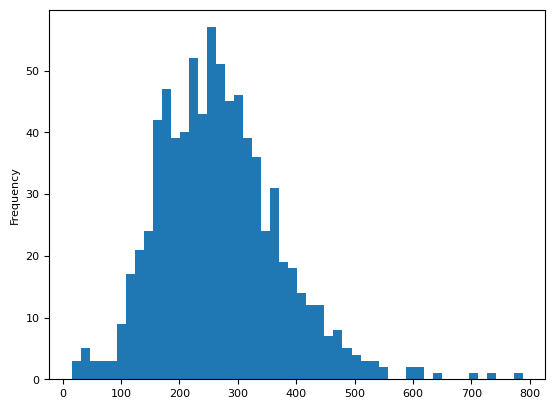

In [ ]:
result_df['V'].plot.hist(bins=50)

In [ ]:
np.sum(result_df['B04_std'])

0.0

<Axes: ylabel='Frequency'>

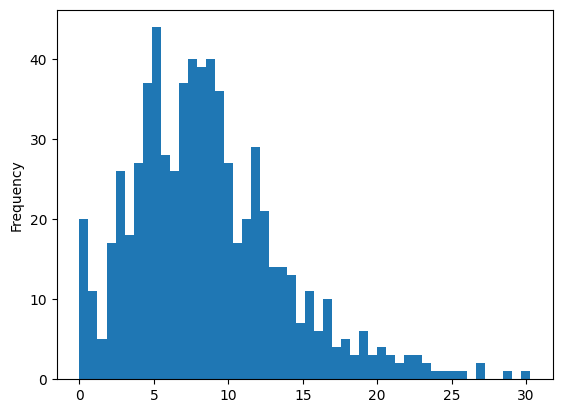

In [ ]:
result_df['B04_std'].plot.hist(bins=50)

In [67]:
selected_columns = [item for item in combinations if ('min' in item) or ('median' in item) or ('std' in item)]

In [68]:
selected_columns

['B02_min',
 'B03_min',
 'B04_min',
 'B05_min',
 'B06_min',
 'B07_min',
 'B08_min',
 'B8A_min',
 'B11_min',
 'B12_min',
 'CHM_min',
 'DEM_min',
 'AGE_min',
 'B02_median',
 'B03_median',
 'B04_median',
 'B05_median',
 'B06_median',
 'B07_median',
 'B08_median',
 'B8A_median',
 'B11_median',
 'B12_median',
 'CHM_median',
 'DEM_median',
 'AGE_median',
 'B02_std',
 'B03_std',
 'B04_std',
 'B05_std',
 'B06_std',
 'B07_std',
 'B08_std',
 'B8A_std',
 'B11_std',
 'B12_std',
 'CHM_std',
 'DEM_std',
 'AGE_std']

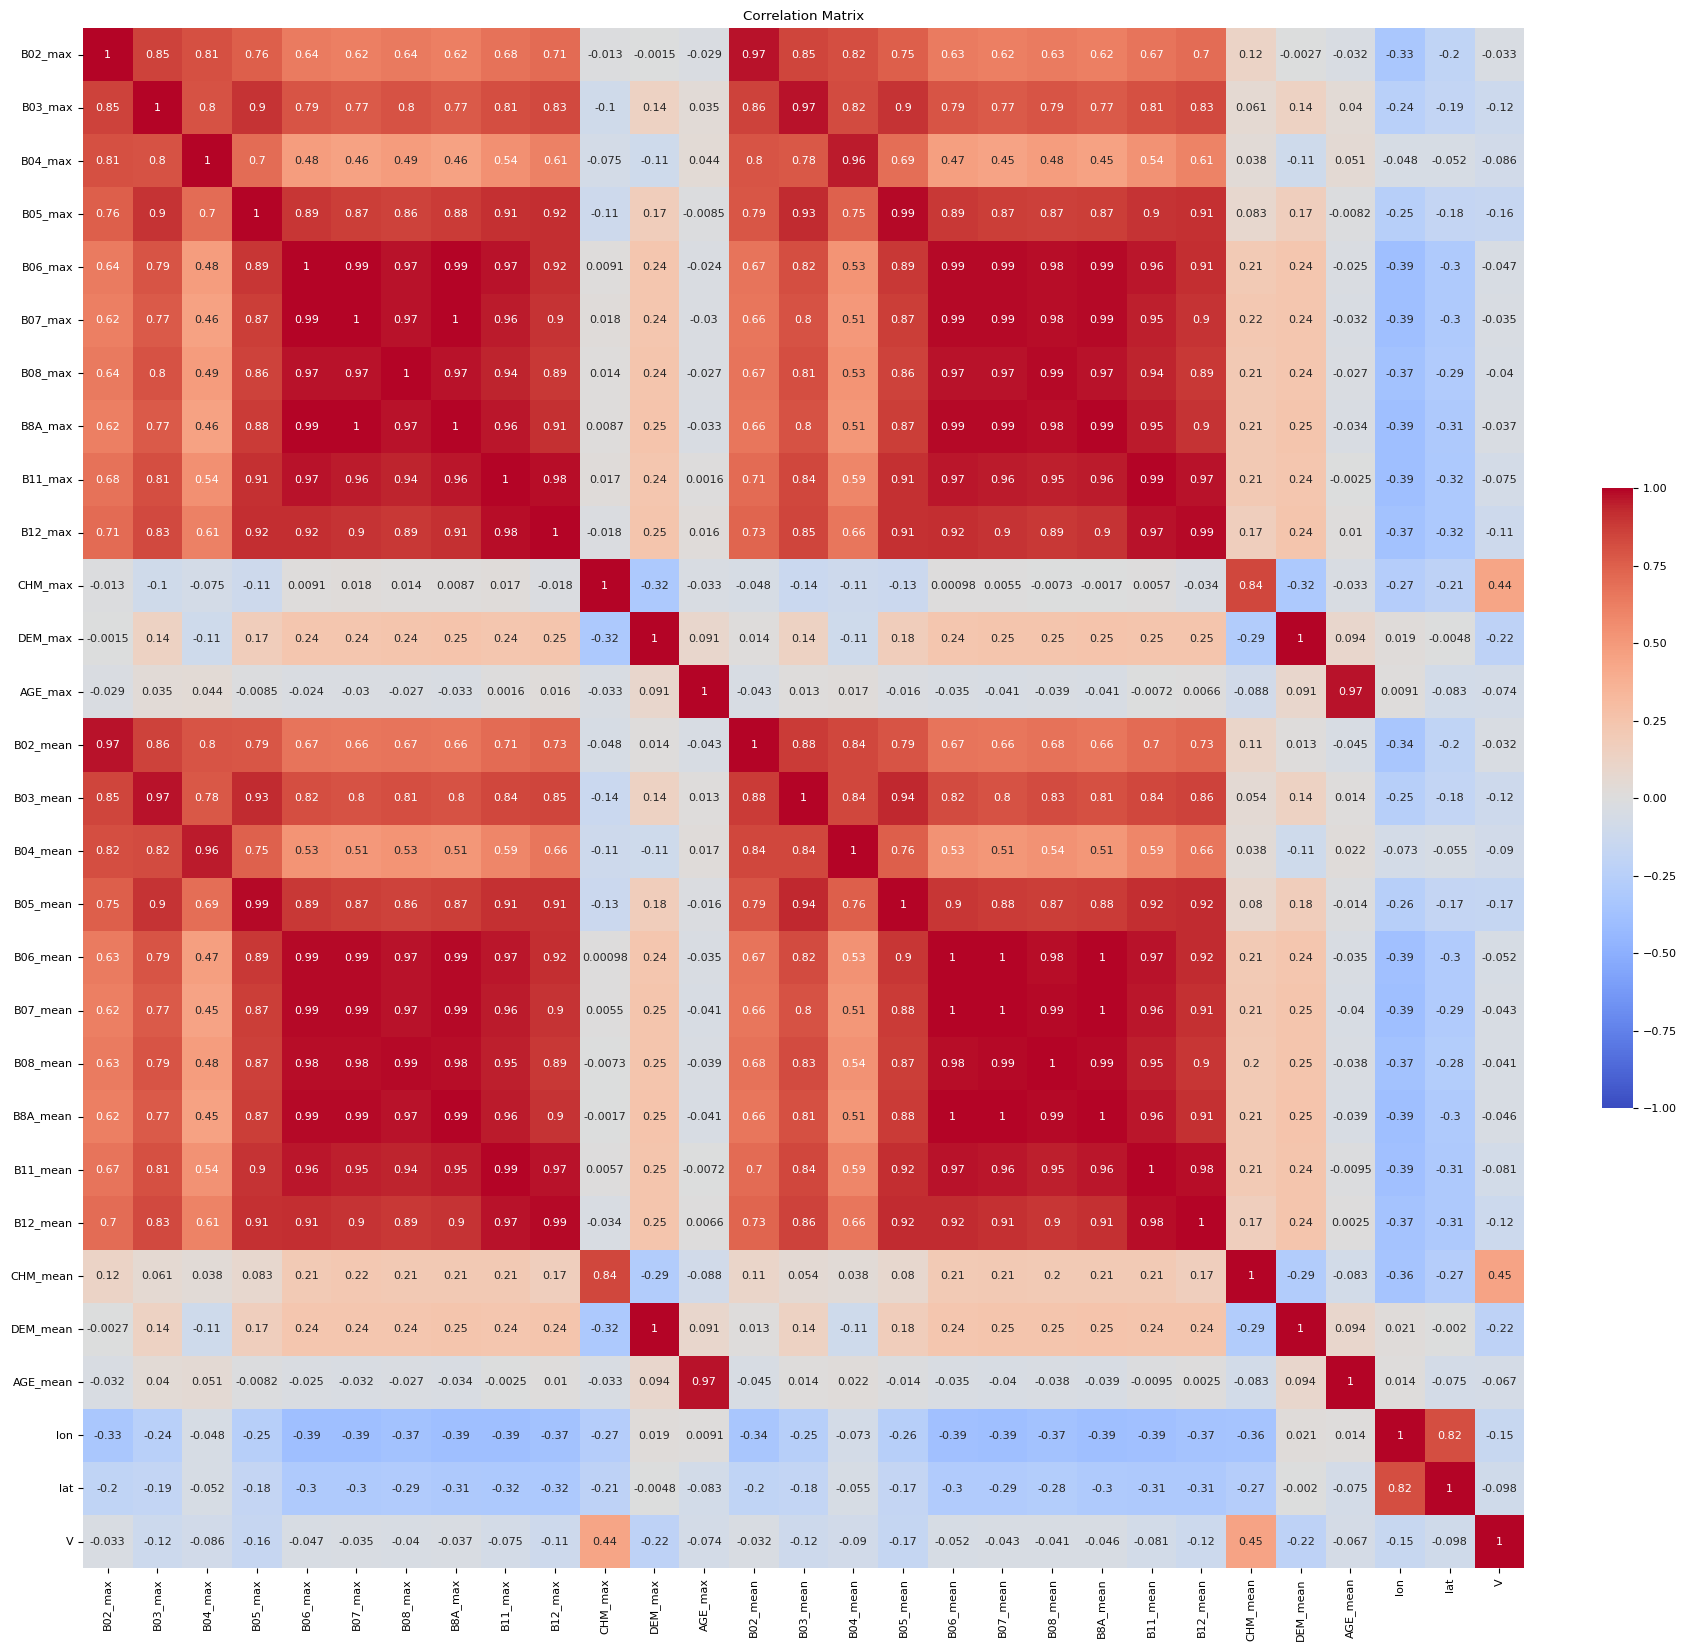

In [69]:
import seaborn as sns

df_corr = result_df.copy()
df_corr = df_corr.drop(columns=selected_columns)
df_corr = df_corr.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(df_corr, cmap='coolwarm', vmin=-1, vmax=1, annot=True, cbar_kws={"fraction": 0.02})
plt.title('Correlation Matrix')
plt.show()

## Train model

In [74]:
! pip install xgboost scikit-learn

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 3.3 MB/s  0:00:00 eta 0:00:01


In [75]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost

In [78]:
# csv_name = 'train_polygon.csv' #'dataset.csv'
csv_name = 'timberstock/data.csv' #'dataset.csv'
dataset = pd.read_csv(csv_name, header=0)

In [79]:
np.random.seed(0)
dataset = dataset.iloc[np.random.permutation(len(dataset))] # shuffle
df_train = dataset[0:int(2*len(dataset)//3)]
df_test = dataset[int(2*len(dataset)//3):]

print('train: ', len(df_train), 'test: ', len(df_test))

# drop target value from features data
y_train = df_train['V']
X_train = df_train.drop(['V'], axis=1)

y_test = df_test['V']
X_test = df_test.drop(['V'], axis=1)

train:  612 test:  306


In [80]:
y_train

306    379
711    181
298    213
466    220
253    451
      ... 
195    255
191    284
536    236
809    298
164    411
Name: V, Length: 612, dtype: int64

In [81]:
X_train

,y,x,H
306,6766713.000,538175.880,18.7
711,6801087.333,559369.459,20.3
298,6766182.057,535689.998,18.1
466,6775078.112,540584.059,16.1
253,6775067.910,516080.890,21.3
...,...,...,...
195,6740705.362,511646.159,19.5
191,6741103.030,511845.358,16.4
536,6779419.223,549837.402,18.9
809,6800105.738,562194.374,19.1


In [82]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(max_depth=3)
decision_tree.fit(X_train, y_train)

pred = decision_tree.predict(X_test)
print('MAPE: ', round(mean_absolute_percentage_error(y_test, pred), 3))
print('MAE: ', round(mean_absolute_error(y_test, pred), 3))

MAPE:  0.337
MAE:  63.801


[Text(0.5, 0.875, 'x[23] <= 16.5\nsquared_error = 9746.828\nsamples = 457\nvalue = 269.923'),
 Text(0.25, 0.625, 'x[29] <= 701.0\nsquared_error = 6264.469\nsamples = 199\nvalue = 225.543'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[38] <= 92.75\nsquared_error = 5652.759\nsamples = 135\nvalue = 247.067'),
 Text(0.0625, 0.125, 'squared_error = 4854.444\nsamples = 83\nvalue = 271.036'),
 Text(0.1875, 0.125, 'squared_error = 4546.194\nsamples = 52\nvalue = 208.808'),
 Text(0.375, 0.375, 'x[49] <= 11.25\nsquared_error = 4516.215\nsamples = 64\nvalue = 180.141'),
 Text(0.3125, 0.125, 'squared_error = 4461.523\nsamples = 22\nvalue = 129.5'),
 Text(0.4375, 0.125, 'squared_error = 2497.937\nsamples = 42\nvalue = 206.667'),
 Text(0.75, 0.625, 'x[36] <= 17.875\nsquared_error = 9741.805\nsamples = 258\nvalue = 304.155'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[8] <= 736.0\nsquared_error = 7784.562\nsamples = 172\nvalue = 284.384'),
 Text(0.5625, 0.125, 'squared_error = 276

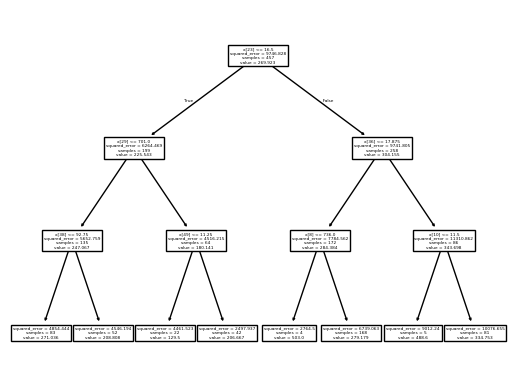

In [ ]:
# from sklearn import tree
# tree.plot_tree(decision_tree)

In [83]:
y_test

106    216
16     351
575    199
656    177
540    142
      ... 
835    238
192    261
629    133
559     99
684    433
Name: V, Length: 306, dtype: int64

In [84]:
pred

array([319.81904762, 514.83333333, 163.84210526, 184.81690141,
       319.81904762, 230.11486486, 230.11486486, 273.01886792,
       273.01886792, 230.11486486, 273.01886792, 273.01886792,
       273.01886792, 364.36363636, 364.36363636, 364.36363636,
       319.81904762, 319.81904762, 273.01886792, 273.01886792,
       184.81690141, 364.36363636, 230.11486486, 273.01886792,
       273.01886792, 364.36363636, 230.11486486, 230.11486486,
       273.01886792, 273.01886792, 184.81690141, 230.11486486,
       230.11486486, 319.81904762, 319.81904762, 230.11486486,
       184.81690141, 273.01886792, 319.81904762, 273.01886792,
       319.81904762, 230.11486486, 364.36363636, 184.81690141,
       319.81904762, 319.81904762, 230.11486486, 273.01886792,
       230.11486486, 514.83333333, 273.01886792, 273.01886792,
       230.11486486, 273.01886792, 514.83333333, 319.81904762,
       184.81690141, 163.84210526, 184.81690141, 230.11486486,
       514.83333333, 230.11486486, 273.01886792, 163.84

Let's try to add cross validation. Please refere to https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.KFold.html